# Pipeline Explanation

This notebook evaluates the robustness of Named Entity Recognition (NER) models when applied to translated text. The pipeline involves the following steps:

1. **Data Loading**: Load the translated dataset containing original and translated article titles in various languages.
2. **Text Cleaning**: Preprocess the titles by removing unwanted elements like parentheses.
3. **NER Model Setup**: Initialize multilingual and English-specific RoBERTa NER pipelines.
4. **NER Extraction**: Apply NER to both original and translated titles to extract entity labels.
5. **Similarity Calculation**: Compute Jaccard similarity based on label counts between original and translated NER outputs.
6. **Analysis and Visualization**: Aggregate results by language, compute mean similarities, and visualize label count comparisons.
7. **Output Saving**: Export the results to a CSV file for further analysis.

This pipeline is used to assess how well NER models maintain performance across translations, which is important for multilingual NLP applications where text may be translated before analysis.

In [ ]:
# import necessary libraries

import pandas as pd
import numpy as np
import re
from collections import Counter
from transformers import pipeline
import torch
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 150)


c:\Users\ajuzi\Downloads\TA_CA2\AI-Regulation-Discourse-in-News-A-Longitudinal-Study-Post-ChatGPT-2020-2025-V2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# load the translated dataset

df = pd.read_csv("../data/mediacloud-translated-completed_taba.csv", encoding="utf-8")

print(df.shape)
print(df["language"].value_counts())
df[["language", "title", "translated_title"]].head()


(44845, 10)
language
es    22494
pt    12068
tr     3085
it     2138
fr     1663
uk      850
ru      819
nl      804
de      766
pl      158
Name: count, dtype: int64


,language,title,translated_title
0,es,Fujian: cómo es el portaaviones de última generación que China sumó a su flota para desafiar el poderío naval de EE.UU. en el Pacífico,Fujian: what is the next-generation aircraft carrier that China added to its fleet to challenge US naval power in the Pacific?
1,es,Cómo quiere Australia prohibir el acceso a las redes sociales a los menores de 16 años,How Australia wants to prohibit access to social networks for those under 16 years of age
2,es,"Los millonarios de Silicon Valley tienen propuestas mesiánicas, pero no dejan de ser negocios que benefician solo al 1% de la humanidad"": Michel N...","The millionaires of Silicon Valley have messianic proposals, but they are still businesses that benefit only 1% of humanity"": Michel Nieva, author..."
3,es,"Tatiana Bilbao: ""La arquitectura puede ser una plataforma para enaltecer la vida, pero también para oprimirla""","Tatiana Bilbao: ""Architecture can be a platform to exalt life, but also to oppress it"""
4,es,Cómo China usó a empresas como Apple para superar a EE.UU. y convertirse en líder mundial de la tecnología,How China used companies like Apple to overtake the US and become a global technology leader


In [ ]:
# clean titles by removing text within parentheses

def clean_text(text):
    if pd.isna(text):
        return ""
    text = re.sub(r"\([^)]*\)", "", text)
    return text.strip()

df["clean_title"] = df["title"].apply(clean_text)
df["clean_translated_title"] = df["translated_title"].apply(clean_text)


In [ ]:
# load the multilingual NER model
ner_multilingual = pipeline(
    "ner",
    model="FacebookAI/xlm-roberta-large-finetuned-conll03-english",
    aggregation_strategy="simple",
    device=0 if torch.cuda.is_available() else -1
)


Loading weights: 100%|██████████| 391/391 [00:02<00:00, 157.52it/s, Materializing param=roberta.encoder.layer.23.output.dense.weight]              
XLMRobertaForTokenClassification LOAD REPORT from: FacebookAI/xlm-roberta-large-finetuned-conll03-english
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# load the English NER model

ner_english = pipeline(
    "ner",
    model="Jean-Baptiste/roberta-large-ner-english",
    aggregation_strategy="simple",
    device=0 if torch.cuda.is_available() else -1
)


c:\Users\ajuzi\Downloads\TA_CA2\AI-Regulation-Discourse-in-News-A-Longitudinal-Study-Post-ChatGPT-2020-2025-V2\.venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ajuzi\.cache\huggingface\hub\models--Jean-Baptiste--roberta-large-ner-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weig

In [ ]:
# function to extract NER labels
def extract_ner_labels(text, ner_model):
    if text.strip() == "":
        return []
    try:
        ents = ner_model(text)
        return [ent["entity_group"] for ent in ents]
    except Exception:
        return []


In [ ]:
# run NER on original and translated titles
print("Running multilingual NER on original titles...")
df["NER_labels_original"] = df["clean_title"].apply(
    lambda x: extract_ner_labels(x, ner_multilingual)
)

print("Running English NER on translated titles...")
df["NER_labels_translated"] = df["clean_translated_title"].apply(
    lambda x: extract_ner_labels(x, ner_english)
)


Running multilingual NER on original titles...
Running English NER on translated titles...


In [ ]:
# function to compute Jaccard similarity based on label counts

def label_count_jaccard(orig_labels, trans_labels):
    """
    Jaccard similarity based on label counts
    """
    c1 = Counter(orig_labels)
    c2 = Counter(trans_labels)

    labels = set(c1) | set(c2)
    intersection = sum(min(c1[l], c2[l]) for l in labels)
    union = sum(max(c1[l], c2[l]) for l in labels)

    return intersection / union if union > 0 else 1.0


In [ ]:
# function to get label counts

def label_count_total(labels):
    return Counter(labels)

df["label_counts_original"] = df["NER_labels_original"].apply(label_count_total)
df["label_counts_translated"] = df["NER_labels_translated"].apply(label_count_total)

df["label_jaccard"] = df.apply(
    lambda r: label_count_jaccard(
        r["NER_labels_original"],
        r["NER_labels_translated"]
    ),
    axis=1
)


In [ ]:
# summarize results by language
summary = (
    df.groupby("language")
      .agg(
          mean_label_jaccard=("label_jaccard", "mean"),
          n_articles=("label_jaccard", "count")
      )
      .reset_index()
      .sort_values("mean_label_jaccard", ascending=False)
)

print("\n=== TRANSFORMER NER TRANSLATION ROBUSTNESS (LABEL-COUNT) ===")
print(summary.round(3))



=== TRANSFORMER NER TRANSLATION ROBUSTNESS (LABEL-COUNT) ===
  language  mean_label_jaccard  n_articles
8       tr               0.864        3085
9       uk               0.845         850
5       pl               0.845         158
7       ru               0.834         819
4       nl               0.827         804
2       fr               0.826        1663
6       pt               0.815       12068
1       es               0.811       22494
3       it               0.719        2138
0       de               0.710         766


In [ ]:
# prepare data for plotting average label counts
def expand_label_counts(counter_series, lang, label):
    return counter_series.apply(lambda c: c.get(label, 0)).mean()

labels = ["PER", "ORG", "LOC", "MISC"]
plot_data = []

for lang in df["language"].unique():
    lang_df = df[df["language"] == lang]
    for label in labels:
        plot_data.append({
            "language": lang,
            "label": label,
            "Original": expand_label_counts(lang_df["label_counts_original"], lang, label),
            "Translated": expand_label_counts(lang_df["label_counts_translated"], lang, label)
        })

plot_df = pd.DataFrame(plot_data)
plot_df = plot_df.melt(
    id_vars=["language", "label"],
    value_vars=["Original", "Translated"],
    var_name="Text Type",
    value_name="Avg Label Count"
)


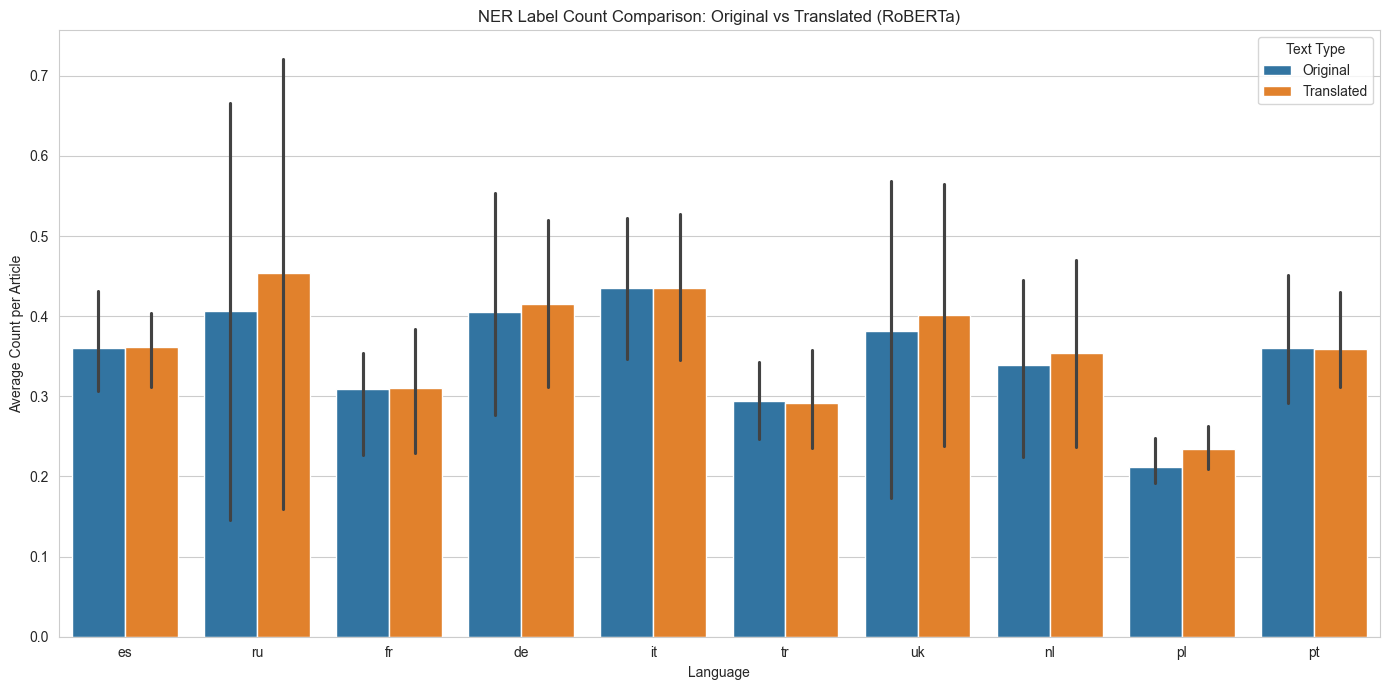

In [12]:
plt.figure(figsize=(14, 7))
sns.barplot(
    data=plot_df,
    x="language",
    y="Avg Label Count",
    hue="Text Type"
)
plt.title("NER Label Count Comparison: Original vs Translated (RoBERTa)")
plt.xlabel("Language")
plt.ylabel("Average Count per Article")
plt.tight_layout()
plt.show()


In [13]:
df_out = df[[
    "language",
    "title",
    "translated_title",
    "label_counts_original",
    "label_counts_translated",
    "label_jaccard"
]]

df_out.to_csv(
    "../data/translation_robustness_roberta_labelcount.csv",
    index=False,
    encoding="utf-8"
)

print("Results saved")


Results saved
